## Imports

In [1]:
from RegionMap import RegionMap
from Fleet import Monitoring_Fleet

import matplotlib.pyplot as plt
import numpy as np
import os 
from datetime import datetime
import pandas as pd

In [2]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## Set up

In [4]:
# Path to load the data

# Amélie
link = r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg"
df_link = pd.read_csv(r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# Amélie PC
# link = r"E:\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"E:\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# # Orane
# link = r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

In [5]:
def run(link, df_link, File, id = 'pred_vdist', mode = 'random', load = True, pretrained_folder = None):

    
    # Set the parameters
    N_episodes = 26 # 26 
    ep_len     = 5

    buffer_size = 6000
    batch_size = 32

    # --- Create maps --- 

    # Map parameters
    x_size = 20
    y_size = 30


    Map = RegionMap(y_size, x_size, [], [], 1, df_link = df_link, link = link, listFileNumbers=File, load = load)
    Map.initialize_better_importance_map(id)

    # ----- Create a fleet -----
    
    drone_init_pos = [[5,7], [3,26], [10, 3], [10,26]]

    state_shape    = [ep_len, 13]    
    num_stacked = 2    
    alpha = 1e-3

    F = Monitoring_Fleet(Map, buffer_size, state_shape, pretrained_folder, lstm = False, gru = True, num_stacked = num_stacked, alpha = alpha)
    F.add_drones(drone_init_pos) 


    #----- Create save folder paths -----
    
    np.set_printoptions(threshold=np.inf)
    
    current_folder = os.getcwd()
    save_folder = current_folder + "/Results"
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)    
        
    now = datetime.now()
    date_time = now.strftime("%m_%d_%Y_%H_%M_%S")    
    
    current_results = save_folder + "/" + date_time
    if not os.path.exists(current_results):
        os.makedirs(current_results)

   #----- Simultaion -----
    
    t_curr = 0
    
    ep_curr = 0 
    
    T = Map.importance_map.shape[0]-1

    list_of_importance_metric = []
    list_of_patrol_metric     = []
    list_of_reward_metric     = []
    
    while ep_curr < N_episodes:

        print('Episode: ',ep_curr)
        
        ep_step = 0
        
        while ep_step < ep_len:  

            # ------------------------------------------------------------------------------------------
            print('Time | ep_step: ', t_curr, ep_step)

            if t_curr % 10 == 0:
                F.plot_fleets_trajectories(t_curr, T, masked=True)
            
            if t_curr == 0:
            
                list_of_observations, list_of_drone_positions = F.get_fleet_info(t_curr, T)
                list_of_drone_states = F.get_drone_states(list_of_observations, list_of_drone_positions)
                visit_matrix = F.visit_matrix
                
                F.update_drone_state_history(list_of_drone_states)                   
            
        #------------- MOVE -------------------------------------------------------------------------------------
            if mode == 'random':
                list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            elif mode == 'greedy':
                list_of_actions = F.move_drones_greedy(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            elif mode == 'zigzag':
                list_of_actions = F.move
            else:
                if t_curr > ep_len:
                    # function works the same for GRU or LSTM, it is just not the same policy network used
                    list_of_actions = F.move_drones_LSTM(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
                
                else:
                    list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)

            #--------------------------------------------------------------------------------------------------------------------
            
            F.update_drone_action_history(list_of_actions)
            
            list_of_observations_, list_of_drone_positions_ = F.get_fleet_info(t_curr+1, T)
            list_of_drone_states_ = F.get_drone_states(list_of_observations_, list_of_drone_positions_)
            visit_matrix_ = F.visit_matrix
            
            F.update_drone_state_history(list_of_drone_states_)
        
            #----- Reward calculation -----
        
            list_of_rewards = F.get_reward(list_of_observations, list_of_observations_, visit_matrix, visit_matrix_, alpha1=1.0, alpha2=0.5)
            
            print(list_of_rewards)
            
            F.update_drone_reward_history(list_of_rewards)
        
            #----- Collect metrics -----
        
            importance_metric, patrol_metric, reward_metric = F.get_metrics(list_of_rewards)
        
            list_of_importance_metric.append(importance_metric)
            list_of_patrol_metric.append(patrol_metric)
            list_of_reward_metric.append(reward_metric)  
            
            #----- Re-assign states for next iteration -----
        
            list_of_observations    = list_of_observations_
            list_of_drone_positions = list_of_drone_positions_
            list_of_drone_states    = list_of_drone_states_
        
            t_curr  += 1 
            ep_step +=1

        #----- Store transitions in the buffer -----
            
        ep_curr += 1
        
        print("-----------")
    
    F.create_data_set()
    
    F.buffer.save(current_results)

    #----- Save metrics -----
    
    np.save(current_results + "/list_of_importance_metric.npy", np.array(list_of_importance_metric))
    np.save(current_results + "/list_of_patrol_metric.npy"    , np.array(list_of_patrol_metric))
    np.save(current_results + "/list_of_reward_metric.npy"    , np.array(list_of_reward_metric))
    np.save(current_results + "/list_of_perc_visited.npy"     , np.array(F.procentage_visited))

## Run

Episode:  0
Time | ep_step:  0 0


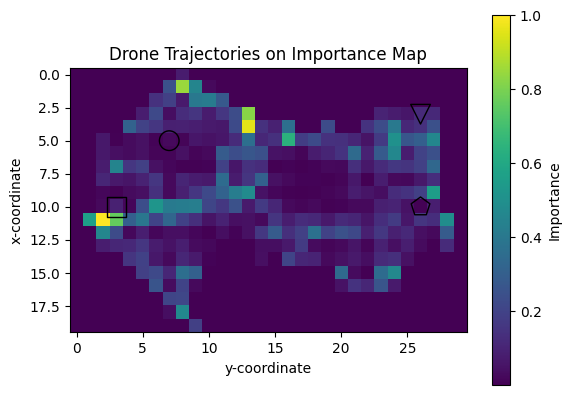

[np.float64(1.5312567632645369), np.float64(-1.3550327271223068), np.float64(8.499181708320975), np.float64(0.9866307484155645)]
Time | ep_step:  1 1
[np.float64(0.37832255009561777), np.float64(-0.7004536693746105), np.float64(-7.678270556032658), np.float64(-2.8023555316030984)]
Time | ep_step:  2 2
[np.float64(4.353738545440137), np.float64(5.695682708715823), np.float64(3.7523522078990945), np.float64(1.5745593687316846)]
Time | ep_step:  3 3
[np.float64(4.586952866986395), np.float64(0.7837054176053471), np.float64(1.5142033696174628), np.float64(-2.041862176562831)]
Time | ep_step:  4 4
[np.float64(-4.99312358768657), np.float64(6.431431338897966), np.float64(7.487090401351452), np.float64(1.6956142730033852)]
-----------
Episode:  1
Time | ep_step:  5 0
[np.float64(11.069912639912218), np.float64(-3.1853049695491786), np.float64(0.4182287961244602), np.float64(5.54166912358167)]
Time | ep_step:  6 1
[np.float64(5.5189963048324), np.float64(0.1249917500000215), np.float64(4.32063

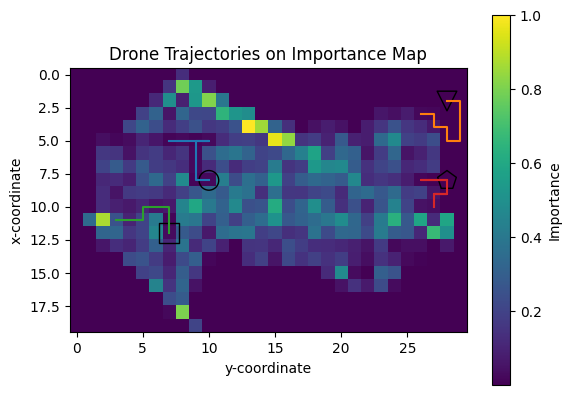

[np.float64(0.4135413542389865), np.float64(-6.499999983589098e-07), np.float64(5.040681341290474), np.float64(0.03159469768509126)]
Time | ep_step:  11 1
[np.float64(-3.276941562443972), np.float64(4.1249997500000015), np.float64(3.6113642565906057), np.float64(3.550031179885209)]
Time | ep_step:  12 2
[np.float64(0.5306221883744006), np.float64(-4.000008064999979), np.float64(-1.3124367706477647), np.float64(4.741250982499998)]
Time | ep_step:  13 3
[np.float64(-2.2379768706858147), np.float64(4.684999988171505e-07), np.float64(-0.2518886953592314), np.float64(6.563430115244012)]
Time | ep_step:  14 4
[np.float64(1.8041386816650635), np.float64(-4.500010524999973), np.float64(4.8473785996437115), np.float64(-0.02028624480285568)]
-----------
Episode:  3
Time | ep_step:  15 0
[np.float64(0.014166782610118278), np.float64(4.2482502465), np.float64(-0.14170418530702444), np.float64(5.1633087998294025)]
Time | ep_step:  16 1
[np.float64(-1.1014460576698197), np.float64(5.014258728499979)

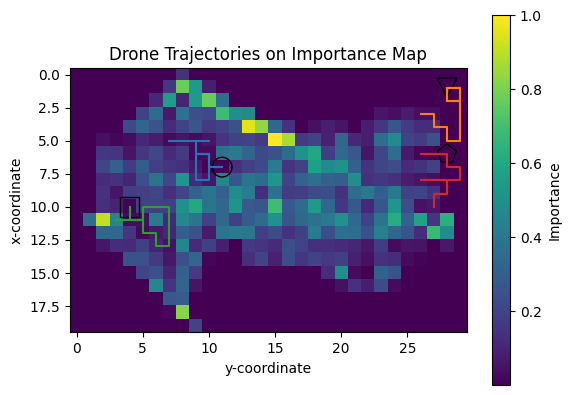

[np.float64(0.0403534043207765), np.float64(3.798249346500003), np.float64(-2.826110722944142), np.float64(0.035991428193239285)]
Time | ep_step:  21 1
[np.float64(-18.39508670046553), np.float64(-4.813518126999955), np.float64(-0.04158398701250565), np.float64(0.03206640224258293)]
Time | ep_step:  22 2
[np.float64(7.839394048932941), np.float64(4.813509001999978), np.float64(-0.3266195057779536), np.float64(3.2412527324999942)]
Time | ep_step:  23 3
[np.float64(0.010644198028370577), np.float64(1.2017522041999937), np.float64(0.22640032781660602), np.float64(7.45369809682931)]
Time | ep_step:  24 4
[np.float64(-7.402963155358657), np.float64(12.48576697149996), np.float64(8.793164218246938), np.float64(-7.453702221829301)]
-----------
Episode:  5
Time | ep_step:  25 0
[np.float64(7.767835092591493), np.float64(-12.11077426642994), np.float64(8.976729590594765), np.float64(6.824999982768538e-07)]
Time | ep_step:  26 1
[np.float64(16.100951260932533), np.float64(-0.20175111349999716), 

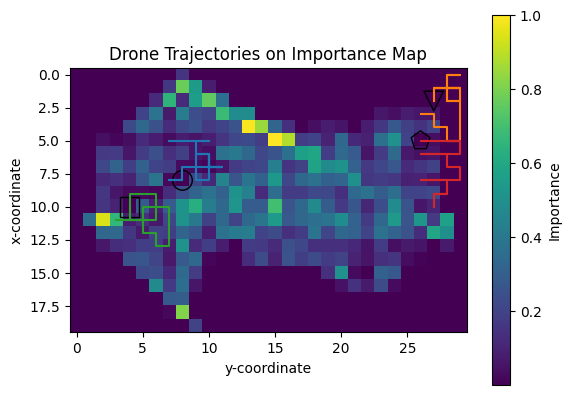

[np.float64(0.26855953931808396), np.float64(7.764865199791114), np.float64(0.35253315735608415), np.float64(-7.614699065084837)]
Time | ep_step:  31 1
[np.float64(14.401710249111055), np.float64(5.661462045667466), np.float64(-5.682349042885009), np.float64(-2.596639587036695)]
Time | ep_step:  32 2
[np.float64(-15.913474979028104), np.float64(-1.1965664102797122), np.float64(4.32526789370179), np.float64(2.703412719904072)]
Time | ep_step:  33 3
[np.float64(13.502421235293147), np.float64(2.308556831906625), np.float64(7.636474283337592), np.float64(11.076312902439454)]
Time | ep_step:  34 4
[np.float64(-2.0324002866446977), np.float64(-8.059962841957288), np.float64(-1.2434890069365456), np.float64(-12.520946846241097)]
-----------
Episode:  7
Time | ep_step:  35 0
[np.float64(-1.2635527814924714), np.float64(-0.6204081140167124), np.float64(-0.17174597907960387), np.float64(9.69334012313496)]
Time | ep_step:  36 1
[np.float64(5.680898340791465), np.float64(3.808586143769133), np.fl

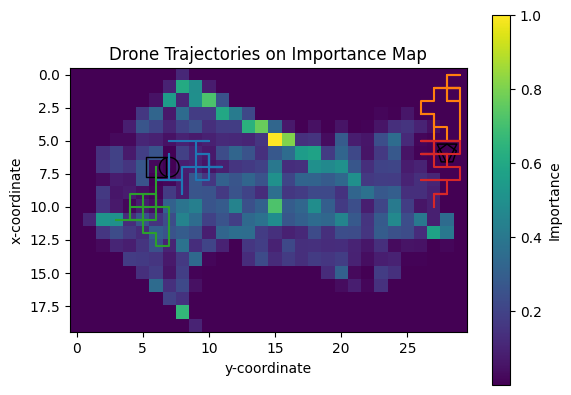

[np.float64(15.166659650132058), np.float64(7.089170062476343), np.float64(9.267379827648401), np.float64(4.389579620710197)]
Time | ep_step:  41 1
[np.float64(-1.4342021119259296), np.float64(0.022693346008207868), np.float64(-8.50432375177741), np.float64(1.7826634335749982)]
Time | ep_step:  42 2
[np.float64(-13.264106348164377), np.float64(9.19748947581646), np.float64(-0.8311630368009197), np.float64(4.118249989602392e-07)]
Time | ep_step:  43 3
[np.float64(3.908042324703187), np.float64(-0.07935643319012392), np.float64(0.3835697913840416), np.float64(-1.6576662603249883)]
Time | ep_step:  44 4
[np.float64(5.262778744855901), np.float64(5.291972436021355), np.float64(6.931213647523894), np.float64(-1.7446114043689875)]
-----------
Episode:  9
Time | ep_step:  45 0
[np.float64(0.5682002055387952), np.float64(-6.5319139870543115), np.float64(4.935224451025947), np.float64(0.07363576158139501)]
Time | ep_step:  46 1
[np.float64(9.660954248751507), np.float64(3.176965350724754), np.f

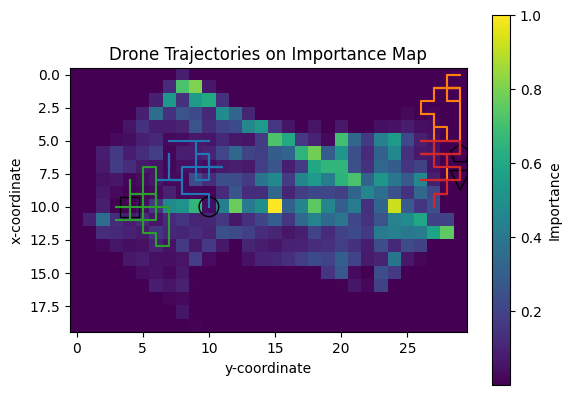

[np.float64(-0.1951897077262399), np.float64(-4.388310629102477), np.float64(12.246262728661673), np.float64(5.136462192436611)]
Time | ep_step:  51 1
[np.float64(-4.876887530088424), np.float64(-0.9618503927424791), np.float64(5.498517236585453), np.float64(0.5020564597636855)]
Time | ep_step:  52 2
[np.float64(7.738687745854258), np.float64(3.320781012144436), np.float64(2.8586906158924066), np.float64(4.592041217568688)]
Time | ep_step:  53 3
[np.float64(-8.31093520373106), np.float64(2.67323669394306), np.float64(5.252144615352159), np.float64(4.304872420830161)]
Time | ep_step:  54 4
[np.float64(11.828019860945641), np.float64(-2.760401613372868), np.float64(-0.8276323273777964), np.float64(-4.9253570942375795)]
-----------
Episode:  11
Time | ep_step:  55 0
[np.float64(0.5925883324816822), np.float64(-1.0500728067852714), np.float64(3.4400753878056984), np.float64(5.67246608088074)]
Time | ep_step:  56 1
[np.float64(4.5510778546672555), np.float64(-1.6439859578444578), np.float64

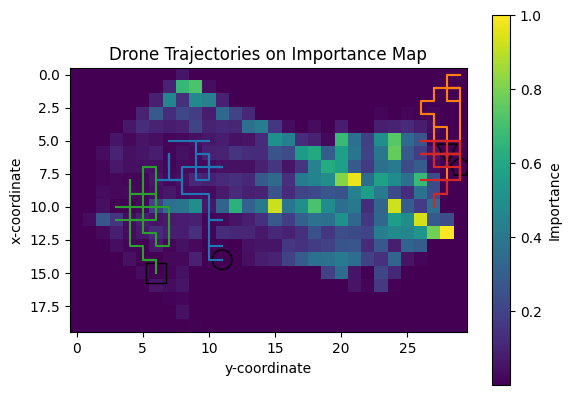

[np.float64(8.516850677716803), np.float64(0.010204114439385167), np.float64(4.316322655882686), np.float64(5.84611435865837)]
Time | ep_step:  61 1
[np.float64(3.927207113633131), np.float64(5.209262962394757), np.float64(4.164951900485904), np.float64(6.156590623304865)]
Time | ep_step:  62 2
[np.float64(-6.499999983589098e-07), np.float64(15.304233332637763), np.float64(-0.24552951527293776), np.float64(10.929772490997856)]
Time | ep_step:  63 3
[np.float64(-3.8828884665563566), np.float64(-16.65937698434224), np.float64(-4.056476784939877), np.float64(0.20684540711665034)]
Time | ep_step:  64 4
[np.float64(-2.544776465100665), np.float64(19.022004669533548), np.float64(8.795750472571898), np.float64(-10.10959889263952)]
-----------
Episode:  13
Time | ep_step:  65 0
[np.float64(5.0595143200258965), np.float64(-1.2260571110668816), np.float64(-8.585142946390633), np.float64(9.189903799217982)]
Time | ep_step:  66 1
[np.float64(2.7733358008768128), np.float64(-0.7565462938504497), np

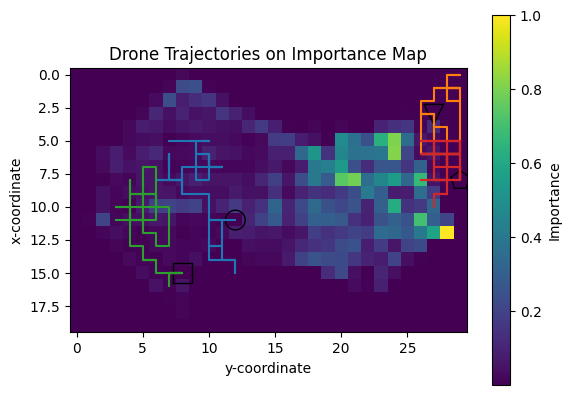

[np.float64(5.320437189191579), np.float64(-3.4101834936488373), np.float64(0.29952497675808754), np.float64(2.971894992496689e-07)]
Time | ep_step:  71 1
[np.float64(1.8937456186860797), np.float64(7.720820147504986), np.float64(-0.0776772736618295), np.float64(1.807439852981978)]
Time | ep_step:  72 2
[np.float64(-3.4621976278722286), np.float64(0.05780030336853356), np.float64(8.047066449210643), np.float64(17.510546493585494)]
Time | ep_step:  73 3
[np.float64(0.5461113866418593), np.float64(-1.4368565395786224), np.float64(4.689076792452783), np.float64(4.374206887923178)]
Time | ep_step:  74 4
[np.float64(-0.6819481042120595), np.float64(-0.6936651505448088), np.float64(1.7665248319474647), np.float64(-8.700465658061088)]
-----------
Episode:  15
Time | ep_step:  75 0
[np.float64(9.581030277414246), np.float64(-0.6539088074211221), np.float64(-1.2167542557920572), np.float64(-8.531442347628262)]
Time | ep_step:  76 1
[np.float64(0.6816891125403346), np.float64(2.853818884655267),

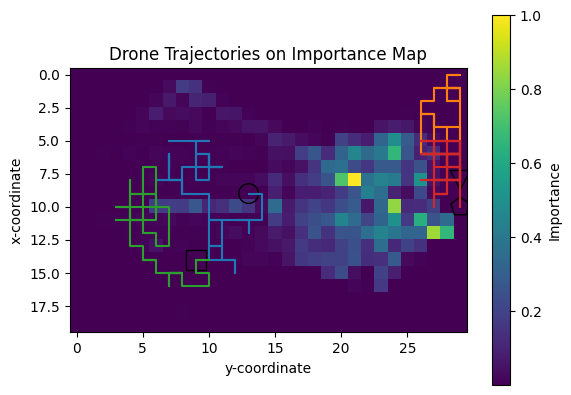

[np.float64(-4.034442252712325), np.float64(0.9010082856299635), np.float64(4.965417828383169), np.float64(12.628653520269438)]
Time | ep_step:  81 1
[np.float64(7.886539054801689), np.float64(-7.374999981379916e-07), np.float64(8.257510766238994), np.float64(-12.809914382769412)]
Time | ep_step:  82 2
[np.float64(5.397240137215704), np.float64(3.167394299774638), np.float64(0.07644088962115346), np.float64(12.94139450716784)]
Time | ep_step:  83 3
[np.float64(4.129626054316759), np.float64(-3.042393148524641), np.float64(4.035436873667139), np.float64(12.181955297297268)]
Time | ep_step:  84 4
[np.float64(-0.3769347559660671), np.float64(7.263749981660792e-07), np.float64(-0.061039548274129635), np.float64(-14.886889592760264)]
-----------
Episode:  17
Time | ep_step:  85 0
[np.float64(4.523560446500777), np.float64(1.6677426656672232), np.float64(-3.799483758164071), np.float64(-5.647656103302321)]
Time | ep_step:  86 1
[np.float64(6.121188773680478), np.float64(-1.214397682474691e-0

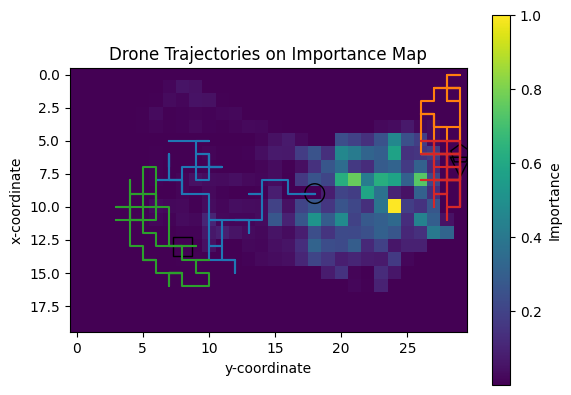

[np.float64(8.639680756255984), np.float64(0.6271565838237079), np.float64(3.632643177780299), np.float64(4.0111272104228954e-07)]
Time | ep_step:  91 1
[np.float64(-2.0017313627526168), np.float64(-0.6271561849212923), np.float64(-0.04113458472381454), np.float64(7.775128297138418)]
Time | ep_step:  92 2
[np.float64(1.6102939656004311), np.float64(0.6271571815060668), np.float64(8.55774511028731), np.float64(8.07499402621538)]
Time | ep_step:  93 3
[np.float64(7.581206945329905), np.float64(5.550526879384174), np.float64(6.492665185005171), np.float64(2.3334555725492825)]
Time | ep_step:  94 4
[np.float64(-7.769264540821315), np.float64(-5.675526770353562), np.float64(2.2411890287650764), np.float64(0.006443307121606068)]
-----------
Episode:  19
Time | ep_step:  95 0
[np.float64(9.93364588096738), np.float64(0.06833614627812527), np.float64(0.012061057100078987), np.float64(0.77216261815713)]
Time | ep_step:  96 1
[np.float64(-0.9497694768011566), np.float64(6.79964507258254e-07), np

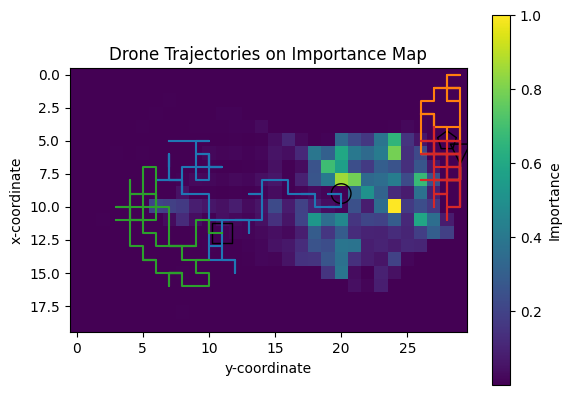

[np.float64(-5.593726912550627), np.float64(-1.5526610818596864), np.float64(3.2245728389873958), np.float64(5.660275068303476)]
Time | ep_step:  101 1
[np.float64(-5.809049759171902), np.float64(6.254651515567994), np.float64(-3.1091420498786255), np.float64(-5.493617291828202)]
Time | ep_step:  102 2
[np.float64(-0.15224262686446277), np.float64(-0.06849581443647043), np.float64(-0.3315462843654975), np.float64(5.277282177327019)]
Time | ep_step:  103 3
[np.float64(0.6261816612817345), np.float64(3.8861718056158328), np.float64(-2.925478842286737), np.float64(1.0902391243642406)]
Time | ep_step:  104 4
[np.float64(1.4484551790803668), np.float64(0.6919656714271732), np.float64(0.09238793286151872), np.float64(8.48521887878356)]
-----------
Episode:  21
Time | ep_step:  105 0
[np.float64(15.999430077616124), np.float64(-4.951394150140156), np.float64(3.262658216764564), np.float64(0.03999217139631302)]
Time | ep_step:  106 1
[np.float64(-19.076596066652613), np.float64(12.502388193782

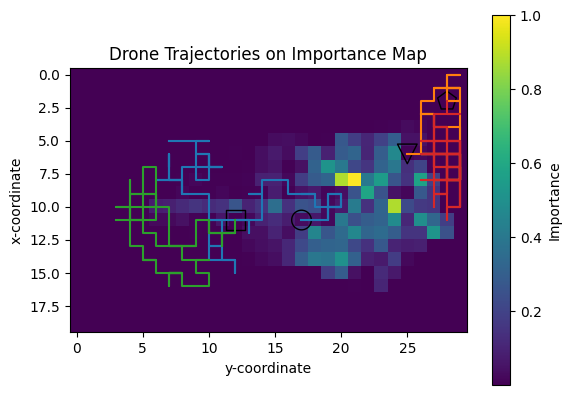

[np.float64(-5.710967876017091), np.float64(2.9111188631504783), np.float64(2.6291995494654463), np.float64(0.9679934360000165)]
Time | ep_step:  111 1
[np.float64(-1.0863769150003804), np.float64(-4.298452744260432), np.float64(-1.475244373966014), np.float64(-4.213674262106103)]
Time | ep_step:  112 2
[np.float64(3.8776281066462417), np.float64(8.287670335732402), np.float64(8.552649719850164), np.float64(-3.6025930102938544)]
Time | ep_step:  113 3
[np.float64(-0.20021298896521322), np.float64(8.393343107774854), np.float64(1.3122497925534848), np.float64(7.200088150149966)]
Time | ep_step:  114 4
[np.float64(2.5701947956159694), np.float64(-0.9344879658892757), np.float64(3.319806257635351), np.float64(-6.825088693774964)]
-----------
Episode:  23
Time | ep_step:  115 0
[np.float64(-2.970162833929058), np.float64(4.1050838008523005), np.float64(-0.1299610378982373), np.float64(9.70637497549377e-07)]
Time | ep_step:  116 1
[np.float64(-4.278126192898118), np.float64(-3.5627955876290

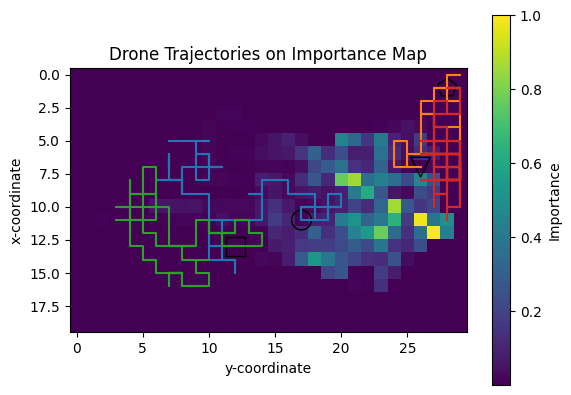

[np.float64(-1.6969704690352079), np.float64(-3.318023421897722), np.float64(3.8863215445690322), np.float64(2.3749965000000093)]
Time | ep_step:  121 1
[np.float64(-3.1880443318784213), np.float64(-0.09258349013562983), np.float64(0.0559879260698478), np.float64(4.25)]
Time | ep_step:  122 2
[np.float64(0.04067174741834406), np.float64(1.0873738938398634), np.float64(-3.6619445353193636), np.float64(-4.125009124999978)]
Time | ep_step:  123 3
[np.float64(8.50980312959105), np.float64(1.8162549214495538), np.float64(1.7093744514855715), np.float64(2.6250041749999915)]
Time | ep_step:  124 4
[np.float64(1.3733662057811766), np.float64(2.03291715505492), np.float64(-1.4589732534587128), np.float64(5.924999985040795e-07)]
-----------
Episode:  25
Time | ep_step:  125 0
[np.float64(14.232762219997124), np.float64(12.468203864074061), np.float64(0.7815539653070641), np.float64(4.062500125000001)]
Time | ep_step:  126 1
[np.float64(-2.6706931027375145), np.float64(3.2264170441175395), np.flo

In [10]:
# Set mode: random, greedy, lstm, nn
mode = 'random'

pretrained_folder = r'\GRU_13_2_10000iter REAL.pth' # r'\GRU_128_3_10000iter.pth'

run(link, df_link, ['000'], id = 'pred_vdist', mode = mode, load = True, pretrained_folder=pretrained_folder)

In [8]:
# list_of_perc_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_perc_visited.npy')
# list_reward_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_reward_metric.npy')
# list_patrol_gru_2 = np.load(r'C:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_patrol_metric.npy')

list_of_perc_gru_2 = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_perc_visited.npy')
list_reward_gru_2 = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_reward_metric.npy')
list_patrol_gru_2 = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_10_2025_19_04_47\list_of_patrol_metric.npy')

In [9]:
list_of_perc_greedy = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_perc_visited.npy')
list_reward_greedy = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_reward_metric.npy')
list_patrol_greedy = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_02_02\list_of_patrol_metric.npy')

In [11]:
list_of_perc_random = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_perc_visited.npy')
list_reward_random = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_reward_metric.npy')
list_patrol_random = np.load(r'D:\GitHub\Projet-CE-1\REAL DATA\Results\06_11_2025_15_06_10\list_of_patrol_metric.npy')

In [12]:
def percentage_above(graphe1, graphe2):

    graphe1 = np.array(graphe1)
    graphe2 = np.array(graphe2)

    if len(graphe1) != len(graphe2):
        raise ValueError("Les deux graphes doivent avoir la même longueur.")

    nb_au_dessus = np.sum(graphe1 > graphe2)
    pourcentage = (nb_au_dessus / len(graphe1)) * 100

    print(f"GRU est au-dessus de LSTM dans {pourcentage:.2f}% des cas.")
    return pourcentage

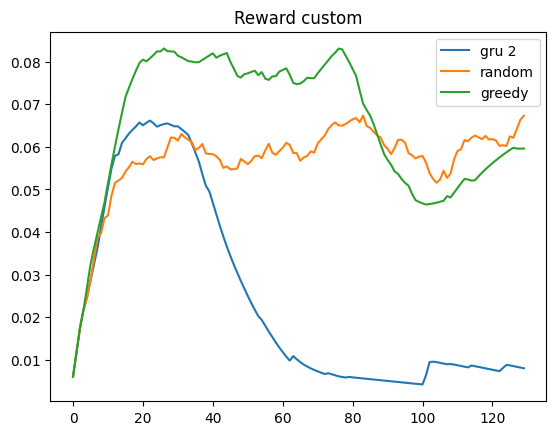

In [13]:
plt.plot(list_patrol_gru_2, label = 'gru 2')
plt.plot(list_patrol_random, label = 'random')
plt.plot(list_patrol_greedy, label = 'greedy')
plt.title('Reward custom')
plt.legend()

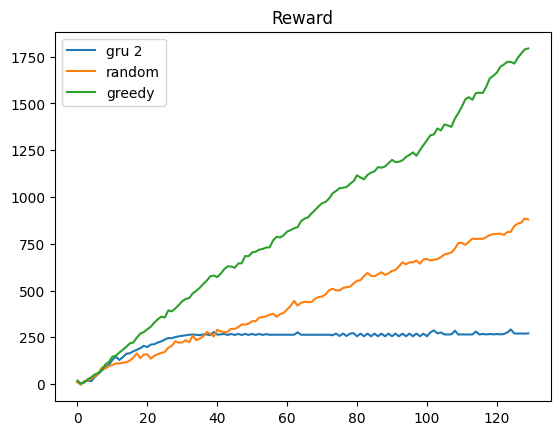

In [14]:
plt.plot(list_reward_gru_2, label = 'gru 2')
plt.plot(list_reward_random, label = 'random')
plt.plot(list_reward_greedy, label = 'greedy')
plt.title('Reward')
plt.legend()

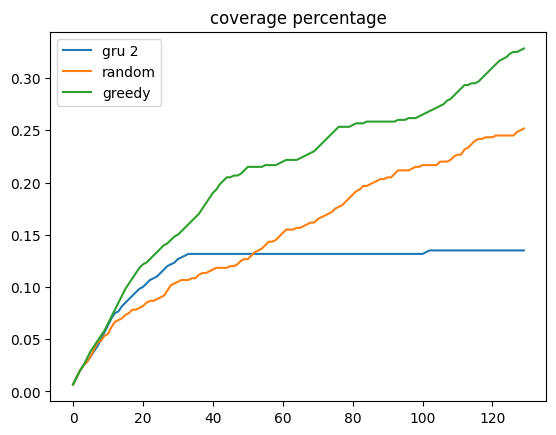

In [15]:
plt.plot(list_of_perc_gru_2, label = 'gru 2')
plt.plot(list_of_perc_random, label = 'random')
plt.plot(list_of_perc_greedy, label = 'greedy')
plt.title('coverage percentage')
plt.legend()